# Sales Forecasting System
## Data Science Internship – Phase 1
### Project Overview
The project analyzes historical sales data and uses machine learning
to predict future sales.
### Objectives
- Analyze historical sales trends
- Clean and preprocess the dataset
- Perform exploratory data analysis
- Extract time-based features
- Build a machine learning model
- Predict future sales
- Evaluate model performance using MAE and RMSE

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("data/SuperStoreOrders.csv")

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [8]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [10]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [14]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


In [16]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

df["order_date"].head()

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: order_date, dtype: datetime64[ns]

In [18]:
df["sales"] = pd.to_numeric(
    df["sales"].astype(str).str.replace(",", ""),
    errors="coerce"
)

df["sales"].head()

0    408
1    120
2     66
3     45
4    114
Name: sales, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      20067 non-null  datetime64[ns]
 2   ship_date       51290 non-null  object        
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [22]:
errors="coerce"

In [24]:
df[["order_date", "sales"]].isnull().sum()

order_date    31223
sales             0
dtype: int64

In [26]:
df = df.sort_values("order_date").reset_index(drop=True)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [28]:
print("Starting Date:", df["order_date"].min())
print("Ending Date:", df["order_date"].max())

Starting Date: 2011-01-01 00:00:00
Ending Date: 2014-12-12 00:00:00


In [30]:
df = pd.read_csv("data/SuperStoreOrders.csv")

df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    errors="coerce"
)

df["sales"] = pd.to_numeric(
    df["sales"].astype(str).str.replace(",", ""),
    errors="coerce"
)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [32]:
df[["order_date", "sales"]].isnull().sum()

order_date    0
sales         0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  object        
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  int64         
 15  qu

In [36]:
df = df.sort_values("order_date").reset_index(drop=True)

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [38]:
print("Starting Date:", df["order_date"].min())
print("Ending Date:", df["order_date"].max())

Starting Date: 2011-01-01 00:00:00
Ending Date: 2014-12-31 00:00:00


In [40]:
print("Total Sales:", df["sales"].sum())
print("Average Sales:", df["sales"].mean())
print("Minimum Sale:", df["sales"].min())
print("Maximum Sale:", df["sales"].max())

Total Sales: 12642905
Average Sales: 246.49844024176252
Minimum Sale: 0
Maximum Sale: 22638


In [44]:
#How much did the company sell each month?
monthly_sales = (
    df.groupby(
        df["order_date"].dt.to_period("M")
    )["sales"]
    .sum()
    .reset_index()
)

monthly_sales.columns = ["Month", "Sales"]

monthly_sales.head()

,Month,Sales
0,2011-01,138245
1,2011-02,134969
2,2011-03,171445
3,2011-04,128843
4,2011-05,148158


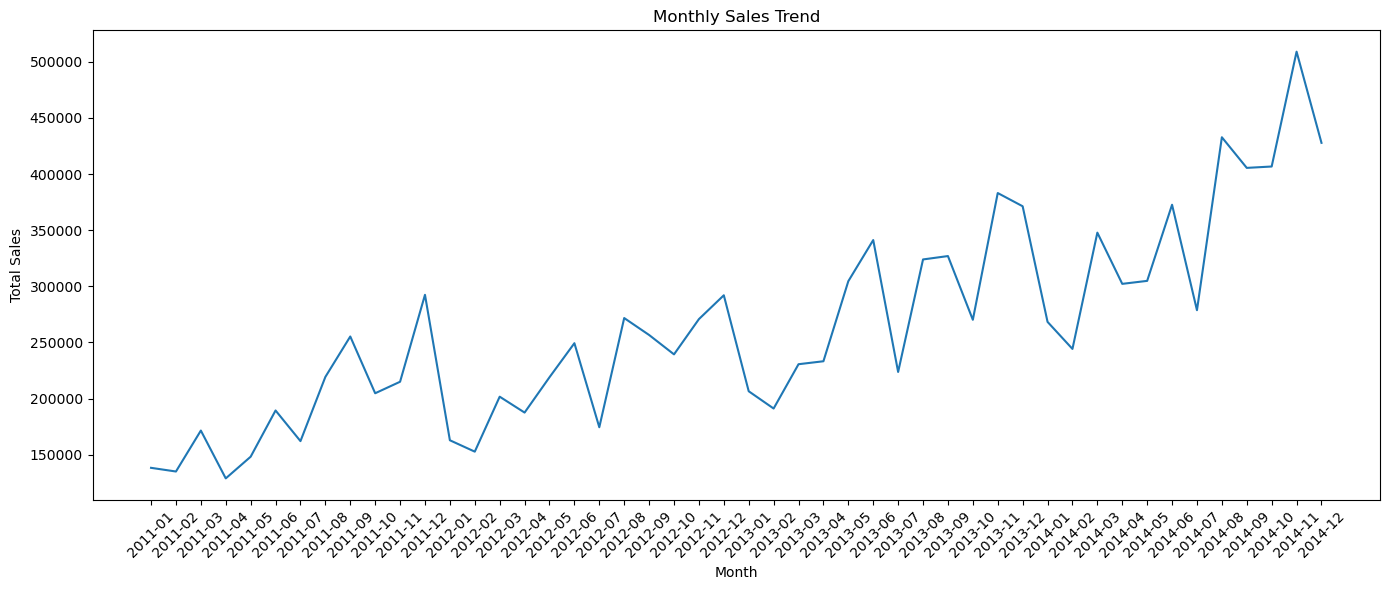

In [46]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Month"].astype(str),
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
highest_month = monthly_sales.loc[
    monthly_sales["Sales"].idxmax()
]

print("Highest Sales Month:")
print(highest_month)

Highest Sales Month:
Month    2014-11
Sales     508985
Name: 46, dtype: object


In [50]:
lowest_month = monthly_sales.loc[
    monthly_sales["Sales"].idxmin()
]

print("Lowest Sales Month:")
print(lowest_month)

Lowest Sales Month:
Month    2011-04
Sales     128843
Name: 3, dtype: object


In [52]:
monthly_average = (
    df.groupby(
        df["order_date"].dt.month
    )["sales"]
    .mean()
)

monthly_average

order_date
1     248.492633
2     246.972327
3     255.198230
4     243.395542
5     247.950482
6     235.566639
7     234.881266
8     264.590032
9     237.578957
10    250.908887
11    243.408481
12    249.977593
Name: sales, dtype: float64

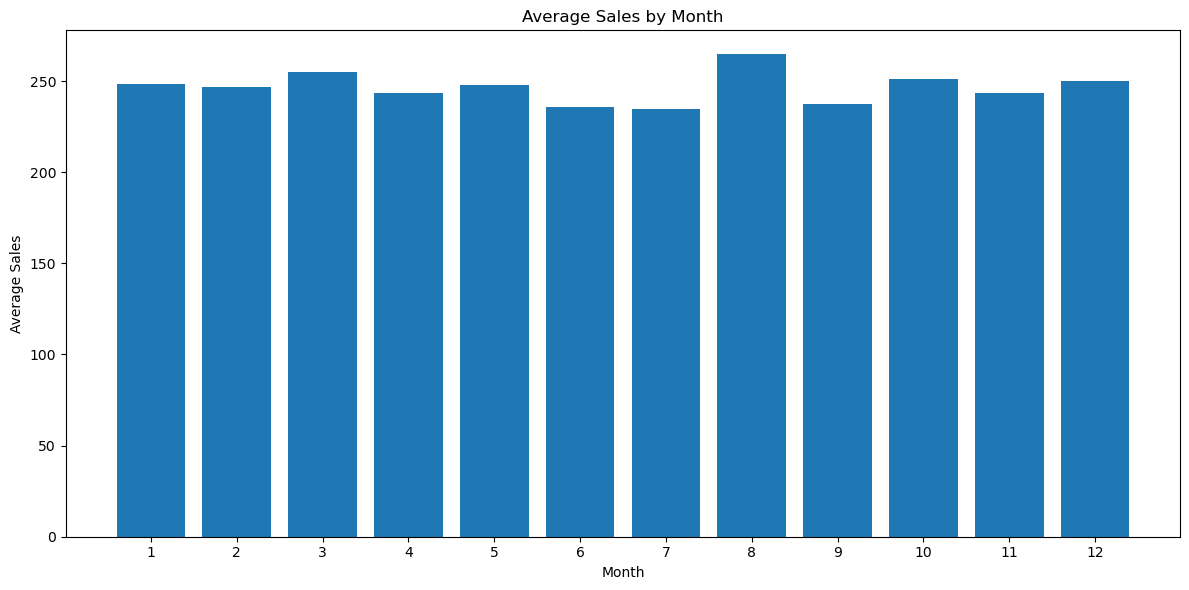

In [54]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_average.index,
    monthly_average.values
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [56]:
monthly_sales["Month"] = pd.to_datetime(monthly_sales["Month"].astype(str))

monthly_sales["Year"] = monthly_sales["Month"].dt.year
monthly_sales["Month_Number"] = monthly_sales["Month"].dt.month

monthly_sales.head()

,Month,Sales,Year,Month_Number
0,2011-01-01,138245,2011,1
1,2011-02-01,134969,2011,2
2,2011-03-01,171445,2011,3
3,2011-04-01,128843,2011,4
4,2011-05-01,148158,2011,5


In [58]:
monthly_sales["Time_Index"] = range(len(monthly_sales))

monthly_sales.head()

,Month,Sales,Year,Month_Number,Time_Index
0,2011-01-01,138245,2011,1,0
1,2011-02-01,134969,2011,2,1
2,2011-03-01,171445,2011,3,2
3,2011-04-01,128843,2011,4,3
4,2011-05-01,148158,2011,5,4


In [60]:
monthly_sales["Previous_Month_Sales"] = (
    monthly_sales["Sales"].shift(1)
)

monthly_sales.head()

,Month,Sales,Year,Month_Number,Time_Index,Previous_Month_Sales
0,2011-01-01,138245,2011,1,0,NaN
1,2011-02-01,134969,2011,2,1,138245.0
2,2011-03-01,171445,2011,3,2,134969.0
3,2011-04-01,128843,2011,4,3,171445.0
4,2011-05-01,148158,2011,5,4,128843.0


In [62]:
monthly_sales = monthly_sales.dropna().reset_index(drop=True)

monthly_sales.head()

,Month,Sales,Year,Month_Number,Time_Index,Previous_Month_Sales
0,2011-02-01,134969,2011,2,1,138245.0
1,2011-03-01,171445,2011,3,2,134969.0
2,2011-04-01,128843,2011,4,3,171445.0
3,2011-05-01,148158,2011,5,4,128843.0
4,2011-06-01,189339,2011,6,5,148158.0


In [64]:
monthly_sales.head(10)

,Month,Sales,Year,Month_Number,Time_Index,Previous_Month_Sales
0,2011-02-01,134969,2011,2,1,138245.0
1,2011-03-01,171445,2011,3,2,134969.0
2,2011-04-01,128843,2011,4,3,171445.0
3,2011-05-01,148158,2011,5,4,128843.0
4,2011-06-01,189339,2011,6,5,148158.0
5,2011-07-01,162039,2011,7,6,189339.0
6,2011-08-01,219236,2011,8,7,162039.0
7,2011-09-01,255250,2011,9,8,219236.0
8,2011-10-01,204679,2011,10,9,255250.0
9,2011-11-01,214931,2011,11,10,204679.0


In [66]:
X = monthly_sales[
    [
        "Time_Index",
        "Month_Number",
        "Previous_Month_Sales"
    ]
]

y = monthly_sales["Sales"]

In [68]:
test_size = 12

X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]

y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 35
Testing records: 12


In [70]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [72]:
y_pred = model.predict(X_test)

In [74]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Square Error (RMSE):", rmse)

Mean Absolute Error (MAE): 48081.9369361214
Root Mean Square Error (RMSE): 56930.18431851874


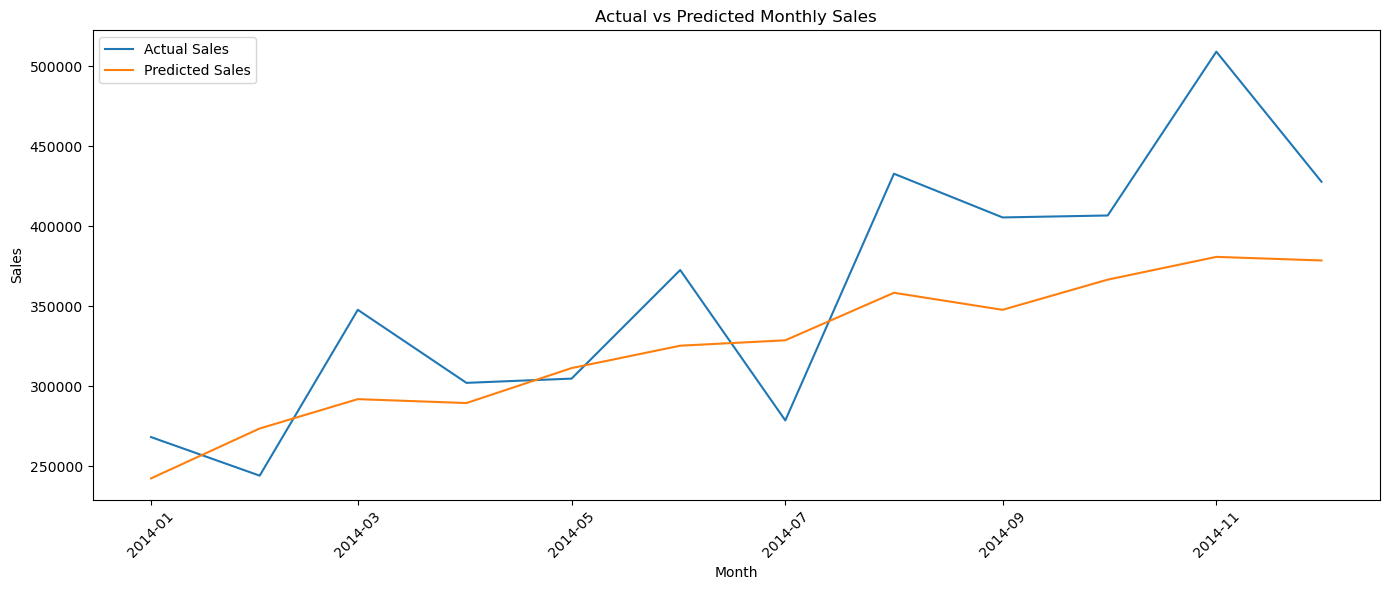

In [76]:
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_sales["Month"].iloc[-test_size:],
    y_test.values,
    label="Actual Sales"
)
plt.plot(
    monthly_sales["Month"].iloc[-test_size:],
    y_pred,
    label="Predicted Sales"
)
plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
# Create the final feature set using all available historical data

X_final = monthly_sales[
    [
        "Time_Index",
        "Month_Number",
        "Previous_Month_Sales"
    ]
]
y_final = monthly_sales["Sales"]

# Train the final Linear Regression model
final_model = LinearRegression()
final_model.fit(X_final, y_final)
print("Final model trained successfully.")

Final model trained successfully.


In [80]:
# the next 12 months after the last historical month

last_month = monthly_sales["Month"].max()
future_months = pd.date_range(
    start=last_month + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)
future_months

DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [82]:
future_predictions = []
previous_sales = monthly_sales["Sales"].iloc[-1]
last_time_index = monthly_sales["Time_Index"].iloc[-1]
for i, month in enumerate(future_months, start=1):
    time_index = last_time_index + i
    month_number = month.month
    features = pd.DataFrame({
        "Time_Index": [time_index],
        "Month_Number": [month_number],
        "Previous_Month_Sales": [previous_sales]
    })
    prediction = final_model.predict(features)[0]
    future_predictions.append(prediction)
    previous_sales = prediction

In [84]:
future_forecast = pd.DataFrame({
    "Month": future_months,
    "Predicted_Sales": future_predictions
})
future_forecast

,Month,Predicted_Sales
0,2015-01-01,316838.725842
1,2015-02-01,348005.489323
2,2015-03-01,359754.636021
3,2015-04-01,374157.394532
4,2015-05-01,388197.510411
5,2015-06-01,402287.185038
6,2015-07-01,416370.086966
7,2015-08-01,430453.914451
8,2015-09-01,444537.615449
9,2015-10-01,458621.333733


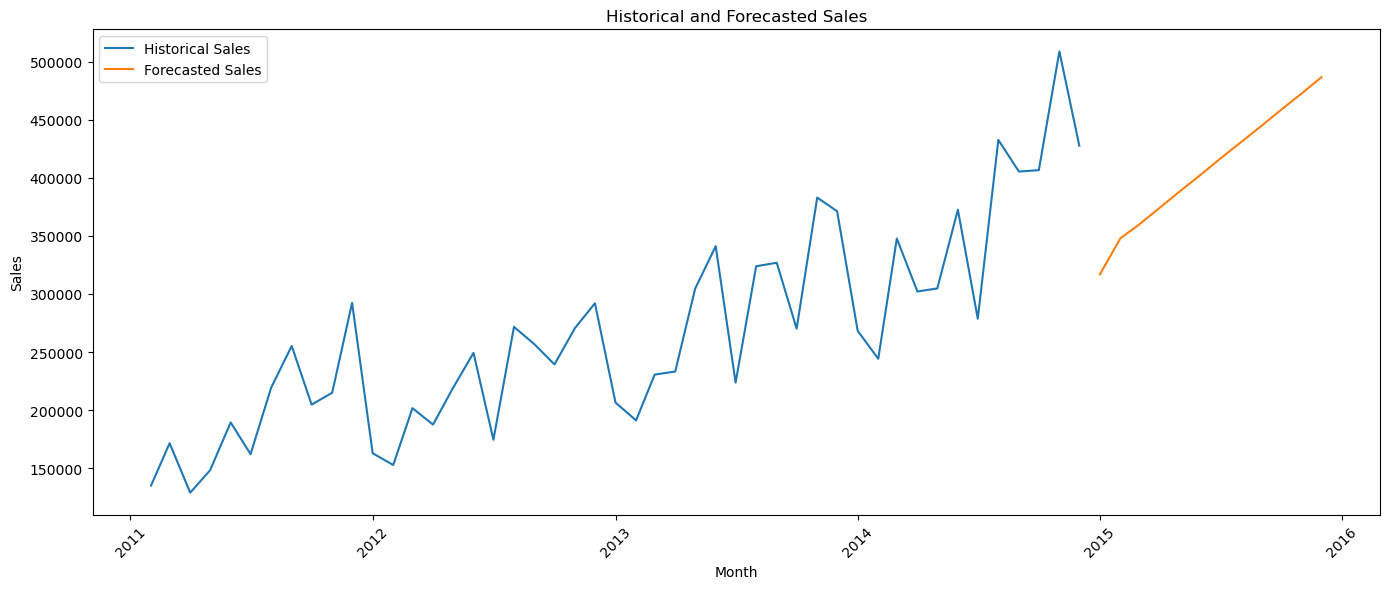

In [86]:
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    label="Historical Sales"
)
plt.plot(
    future_forecast["Month"],
    future_forecast["Predicted_Sales"],
    label="Forecasted Sales"
)
plt.title("Historical and Forecasted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
highest_forecast = future_forecast.loc[
    future_forecast["Predicted_Sales"].idxmax()
]
print("Highest Predicted Sales Month:")
print(highest_forecast)

Highest Predicted Sales Month:
Month              2015-12-01 00:00:00
Predicted_Sales          486788.765899
Name: 11, dtype: object


In [90]:
lowest_forecast = future_forecast.loc[
    future_forecast["Predicted_Sales"].idxmin()
]
print("Lowest Predicted Sales Month:")
print(lowest_forecast)

Lowest Predicted Sales Month:
Month              2015-01-01 00:00:00
Predicted_Sales          316838.725842
Name: 0, dtype: object


In [92]:
future_forecast.to_csv(
    "future_sales_forecast.csv",
    index=False
)
print("Forecast saved successfully.")

Forecast saved successfully.


In [94]:
from sklearn.ensemble import RandomForestRegressor

In [96]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [98]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)
print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)

Random Forest MAE: 61848.857500000006
Random Forest RMSE: 74329.85790292289


In [100]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse
    ]
})
comparison

,Model,MAE,RMSE
0,Linear Regression,48081.936936,56930.184319
1,Random Forest,61848.857500,74329.857903


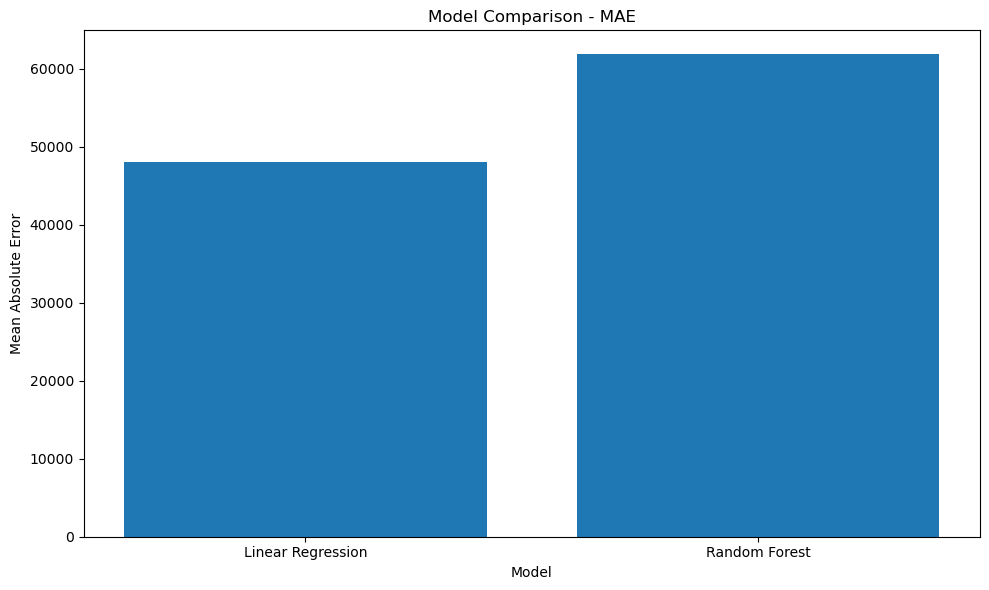

In [102]:
plt.figure(figsize=(10, 6))
plt.bar(
    comparison["Model"],
    comparison["MAE"]
)
plt.title("Model Comparison - MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")
plt.tight_layout()
plt.show()

## Final Sales Forecast

Linear Regression was selected as the final forecasting model because it achieved lower MAE and RMSE than Random Forest.

The final model is trained using the available historical monthly sales data and is used to forecast sales for the next 12 months.


In [105]:
# Train final Linear Regression model

final_model = LinearRegression()
final_model.fit(X_final, y_final)
print("Final Linear Regression model trained successfully.")

Final Linear Regression model trained successfully.


In [107]:
final_forecast = future_forecast.copy()
final_forecast["Predicted_Sales"] = final_forecast[
    "Predicted_Sales"
].round(2)
final_forecast

,Month,Predicted_Sales
0,2015-01-01,316838.73
1,2015-02-01,348005.49
2,2015-03-01,359754.64
3,2015-04-01,374157.39
4,2015-05-01,388197.51
5,2015-06-01,402287.19
6,2015-07-01,416370.09
7,2015-08-01,430453.91
8,2015-09-01,444537.62
9,2015-10-01,458621.33


In [109]:
print("Forecast Period:")
print(
    final_forecast["Month"].min().strftime("%B %Y"),
    "to",
    final_forecast["Month"].max().strftime("%B %Y")
)
print(
    "\nHighest Predicted Sales:",
    final_forecast["Predicted_Sales"].max()
)
print(
    "Lowest Predicted Sales:",
    final_forecast["Predicted_Sales"].min()
)

Forecast Period:
January 2015 to December 2015

Highest Predicted Sales: 486788.77
Lowest Predicted Sales: 316838.73


In [111]:
final_forecast.to_csv(
    "final_sales_forecast_2015.csv",
    index=False
)
print("Final forecast saved successfully.")

Final forecast saved successfully.


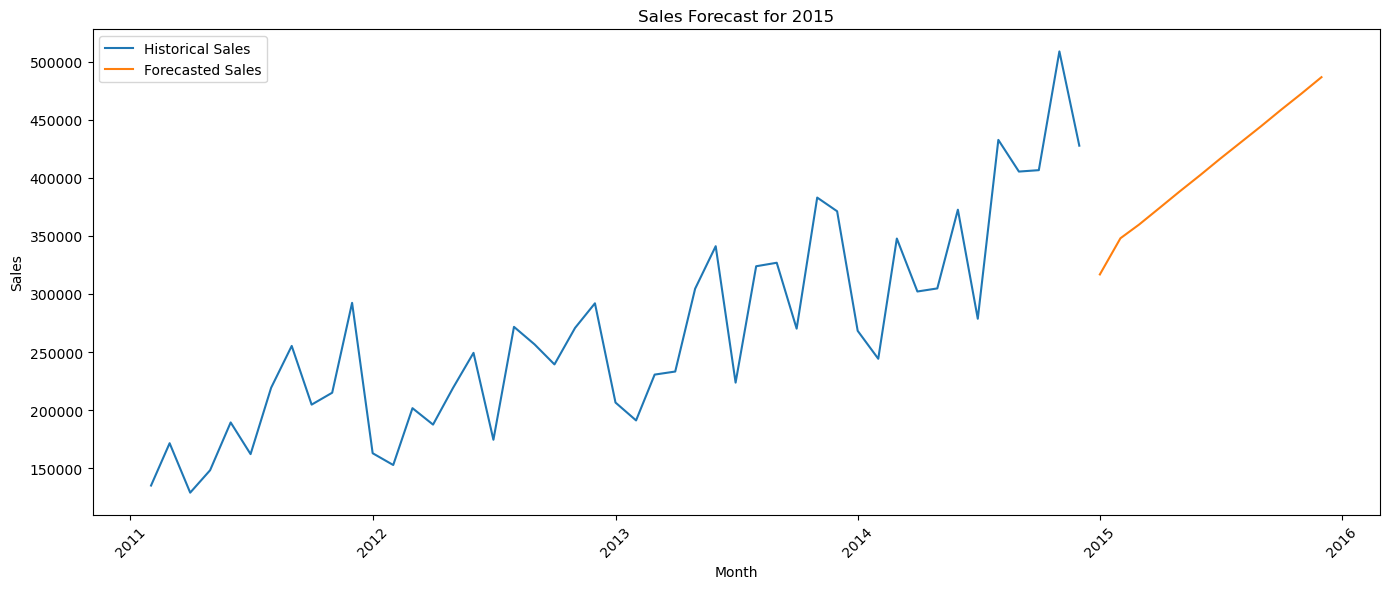

In [113]:
plt.figure(figsize=(14, 6))
plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    label="Historical Sales"
)
plt.plot(
    final_forecast["Month"],
    final_forecast["Predicted_Sales"],
    label="Forecasted Sales"
)
plt.title("Sales Forecast for 2015")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()